In [1]:
feature_names = [
                "ISOTOPE",
                "atomic num >103",
                "Group IVa,Va,VIa Rows 4-6 ",
                "actinide",
                "Group IIIB,IVB",
                "Lanthanide",
                "Group VB,VIB,VIIB",
                "QAAA@1",
                "Group VIII (Fe...)",
                "Group IIa (Alkaline earth)",
                "4M Ring",
                "Group IB,IIB (Cu..)",
                "ON(C)C",
                "S-S",
                "OC(O)O",
                "QAA@1",
                "CTC",
                "Group IIIA (B...) ",
                "7M Ring",
                "Si",
                "C=C(Q)Q",
                "3M Ring",
                "NC(O)O",
                "N-O",
                "NC(N)N",
                "C$=C($A)$A",
                "I",
                "QCH2Q",
                "P",
                "CQ(C)(C)A",
                "QX",
                "CSN",
                "NS",
                "CH2=A",
                "Group IA (Alkali Metal)",
                "S Heterocycle",
                "NC(O)N",
                "NC(C)N",
                "OS(O)O",
                "S-O",
                "CTN",
                "F",
                "QHAQH",
                "OTHER",
                "C=CN",
                "BR",
                "SAN",
                "OQ(O)O",
                "CHARGE  ",
                "C=C(C)C",
                "CSO",
                "NN",
                "QHAAAQH",
                "QHAAQH",
                "OSO",
                "ON(O)C",
                "O Heterocycle",
                "QSQ",
                "Snot%A%A",
                "S=O",
                "AS(A)A",
                "A$!A$A",
                "N=O",
                "A$A!S",
                "C%N",
                "CC(C)(C)A",
                "QS",
                "QHQH",
                "QQH",
                "QNQ",
                "NO",
                "OAAO",
                "S=A",
                "CH3ACH3",
                "A!N$A",
                "C=C(A)A",
                "NAN",
                "C=N",
                "NAAN",
                "NAAAN",
                "SA(A)A",
                "ACH2QH",
                "QAAAA@1",
                "NH2",
                "CN(C)C",
                "CH2QCH2",
                "X!A$A",
                "S",
                "OAAAO",
                "QHAACH2A",
                "QHAAACH2A",
                "OC(N)C",
                "QCH3",
                "QN",
                "NAAO",
                "5 M ring",
                "NAAAO",
                "QAAAAA@1",
                "C=C",
                "ACH2N",
                "8M Ring or larger",
                "QO",
                "CL",
                "QHACH2A",
                "A$A($A)$A",
                "QA(Q)Q",
                "XA(A)A",
                "CH3AAACH2A",
                "ACH2O",
                "NCO",
                "NACH2A",
                "AA(A)(A)A",
                "Onot%A%A",
                "CH3CH2A",
                "CH3ACH2A",
                "CH3AACH2A",
                "NAO",
                "ACH2CH2A > 1",
                "N=A",
                "Heterocyclic atom > 1",
                "N Heterocycle",
                "AN(A)A",
                "OCO",
                "QQ",
                "Aromatic Ring > 1",
                "A!O!A",
                "A$A!O > 1",
                "ACH2AAACH2A",
                "ACH2AACH2A",
                "QQ > 1",
                "QH > 1",
                "OACH2A",
                "A$A!N",
                "X (HALOGEN)",
                "Nnot%A%A",
                "O=A>1 ",
                "Heterocycle",
                "QCH2A>1",
                "OH",
                "O > 3",
                "CH3 > 2",
                "N > 1",
                "A$A!O",
                "Anot%A%Anot%A",
                "6M ring > 1",
                "O > 2",
                "ACH2CH2A",
                "AQ(A)A",
                "CH3 > 1",
                "A!A$A!A",
                "NH",
                "OC(C)C",
                "QCH2A",
                "C=O",
                "A!CH2!A",
                "NA(A)A",
                "C-O",
                "C-N",
                "O>1",
                "CH3",
                "N",
                "Aromatic",
                "6M Ring",
                "O",
                "Ring",
                "Fragments",
            ]
column_mapping = {f"maccsfingerprint{i}": feature_names[i] for i in range(len(feature_names))}

In [2]:
root_dir = '../../../data'
target = 'capacity_max'

metrics = ["pairwise_accuracy_score", "ndcg_score", "rmse", "mape"]
models = ["random_forest", "xgboost"]

data_dict = {
  'expert': 'data_experts1.csv',
  'zhu': 'data_zhu.csv',
  'saad': 'data_saad.csv',
  'expert2': 'data_experts2.csv',
  'expert3': 'data_experts3.csv',
}

fp_maccs = 'fingerprints_maccs'

combo = ['expert', 'expert2']

In [3]:
import shap
import numpy as np

# def visualize_shap(shap_values_list, df_features, columns_mapping=None):
#     test_set, shap_set = np.array(shap_values_list[0][1]), np.array(shap_values_list[0][0])
#     for i in range(0,len(shap_values_list)):
#         i_test_set, i_shap_set = np.array(shap_values_list[i][1]), shap_values_list[i][0]
#         display(shap.plots.beeswarm(i_shap_set))

def visualize_shap(shap_values_list, df_features, columns_mapping=None):
    test_ids = []
    shap_values_per_fold = []
    for i in range(len(shap_values_list)):
        shaps = shap_values_list[i][0]
        shap_values_per_fold.extend(shaps)
        test_ids.extend(shap_values_list[i][1])

    display(shap.summary_plot(np.array(shap_values_per_fold),
                      df_features.loc[test_ids, :],
                      max_display=10,
                      feature_names=list(columns_mapping.values()),
                      show=True))

/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import pandas as pd
import os

dataset_paths = {data_name: os.path.join(root_dir, fp_maccs, data_dict[data_name]) for data_name in combo}
dfs = {}
for data_name, data_path in dataset_paths.items():
    df = pd.read_csv(data_path)
    df.columns = df.columns.str.replace(r"[\[\]>]", "", regex=True)
    df = df.sort_values(by="smiles").reset_index(drop=True)
    dfs[data_name] = df

df_expert1 = dfs["expert"]
df_expert2 = dfs["expert2"]

In [5]:
from modules.predictor.data.utils import custom_data_kfold, combine_split

num_splits = 4
num_bins = 4
random_state = 42

folds_experts1 = custom_data_kfold(df_expert1, df_expert1.loc[:, [target]], num_splits, num_bins, random_state)
folds_all, df_all = combine_split(df_expert1, folds_experts1, df_expert2)

bin_features = []
num_features = []

In [6]:
X_all = df_all.drop(columns=[target, "smiles"])
y_all = df_all.loc[:, [target]]

In [7]:
X_all

,maccsfingerprint0,maccsfingerprint1,maccsfingerprint2,maccsfingerprint3,maccsfingerprint4,maccsfingerprint5,maccsfingerprint6,maccsfingerprint7,maccsfingerprint8,maccsfingerprint9,...,maccsfingerprint156,maccsfingerprint157,maccsfingerprint158,maccsfingerprint159,maccsfingerprint160,maccsfingerprint161,maccsfingerprint162,maccsfingerprint163,maccsfingerprint164,maccsfingerprint165
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,1,1,1,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,1,1,1,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,1,1,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,1,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,1,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,1,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,1,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,1,0


In [8]:
from modules.predictor.training_and_evaluation.train_eval import CrossValidationPipeline

cv_rf = CrossValidationPipeline(
    X_all,
    y_all,
    num_features,
    bin_features,
    folds_all,
    metrics,
    "",
    "maccs_expert_expert2",
    oversampling=False,
    explainability=True,
    hyperparam_opt=(True, "grid_search"),
    verbose=True
)

cv_xgboost = CrossValidationPipeline(
    X_all,
    y_all,
    num_features,
    bin_features,
    folds_all,
    metrics,
    "",
    "maccs_expert_expert2",
    oversampling=False,
    explainability=True,
    hyperparam_opt=(True, "grid_search"),
    verbose=True
)

In [10]:
from modules.predictor.training_and_evaluation.explanations import explain_model
from modules.predictor.training_and_evaluation.model_factory import Models
import copy

_, model, param_grid = Models().get_model('random_forest')

# X, _ = self.preprocess_data(X, None)
model = cv_rf.tune_model(copy.deepcopy(X_all), copy.deepcopy(y_all), model, param_grid)

model.fit(X_all, y_all[y_all.columns[0]])
shap_values_all = explain_model(model, X_all)

Best score: -0.7837004377247309
 Best params: {'bootstrap': False, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 50}


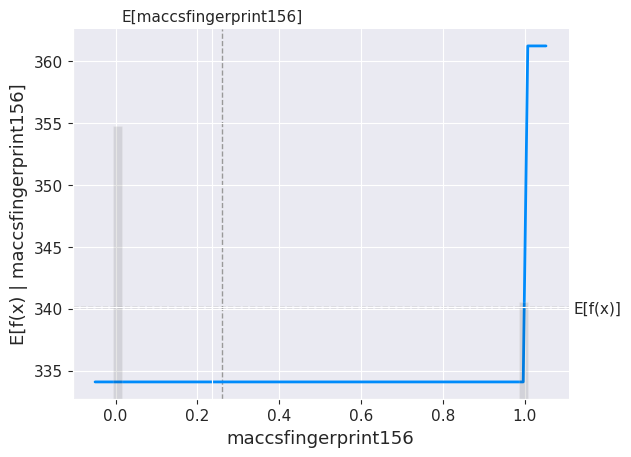

In [21]:
explainer_xgb = shap.TreeExplainer(model)
shap_values_xgb = explainer_xgb(X_all)

# make a standard partial dependence plot with a single SHAP value overlaid
shap.partial_dependence_plot(
    "maccsfingerprint156",
    model.predict,
    X_all,
    model_expected_value=True,
    feature_expected_value=True,
    show=True,
    ice=False,
)

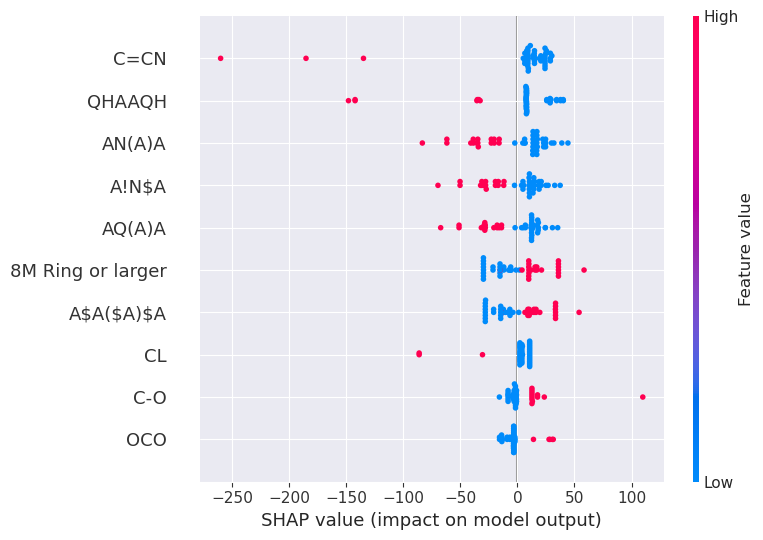

In [11]:
shap.summary_plot(np.array(shap_values_all),
                      X_all,
                      max_display=10,
                      feature_names=list(column_mapping.values()),
                      show=True)

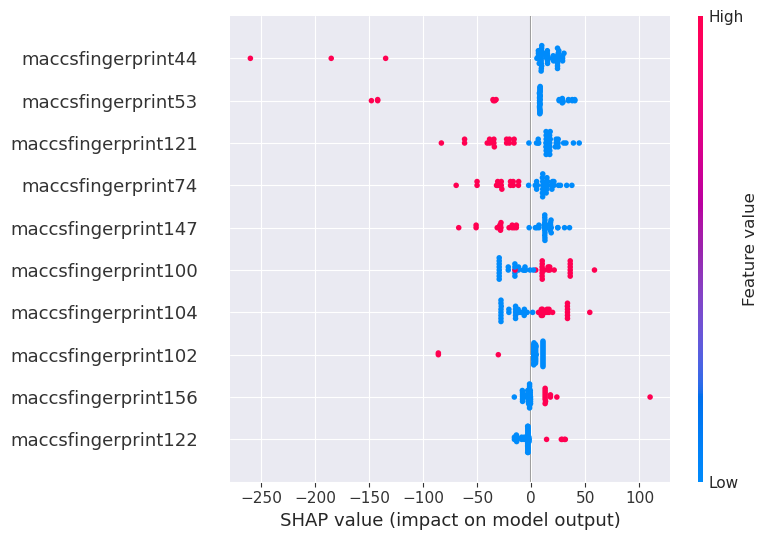

In [13]:
shap.summary_plot(np.array(shap_values_all),
                      X_all,
                      max_display=10,
                      feature_names=list(column_mapping.keys()),
                      show=True)

In [9]:
results_rf = cv_rf.train_pipeline(models[0])
f_importance_rf = cv_rf.shap_values

Training model Random Forest Regressor
Best score: -1.1160727930353804
 Best params: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 10}
Best score: -1.4240689391785082
 Best params: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 25}
Best score: -0.6405451360488649
 Best params: {'bootstrap': False, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}
Best score: -0.5791051343953977
 Best params: {'bootstrap': False, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}


In [10]:
print(results_rf)

{'pairwise_accuracy_score': 0.7917, 'baseline_mean_pairwise_accuracy_score': 0.5, 'baseline_median_pairwise_accuracy_score': 0.5, 'ndcg_score': 0.9678, 'baseline_mean_ndcg_score': 0.8519, 'baseline_median_ndcg_score': 0.8519, 'rmse': 76.4029, 'baseline_mean_rmse': 110.5105, 'baseline_median_rmse': 111.3042, 'mape': 0.1604, 'baseline_mean_mape': 0.26, 'baseline_median_mape': 0.26, 'selected_features': 'all'}


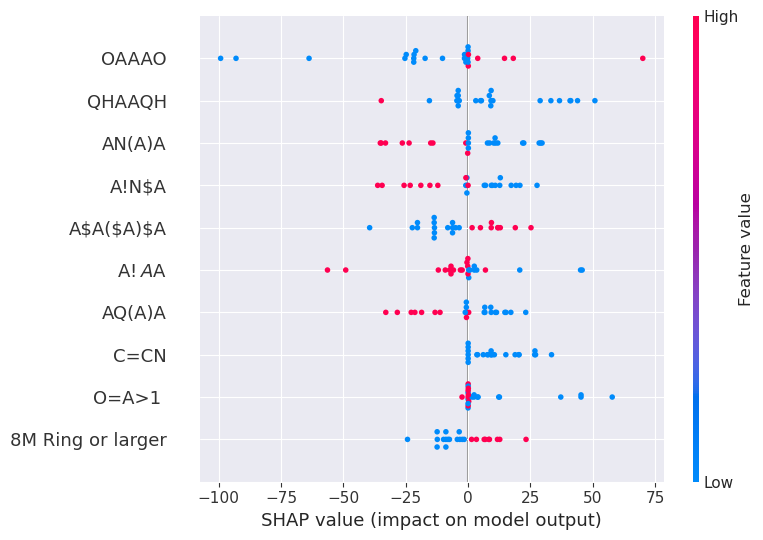

None

In [31]:
visualize_shap(f_importance_rf, X_all, column_mapping)

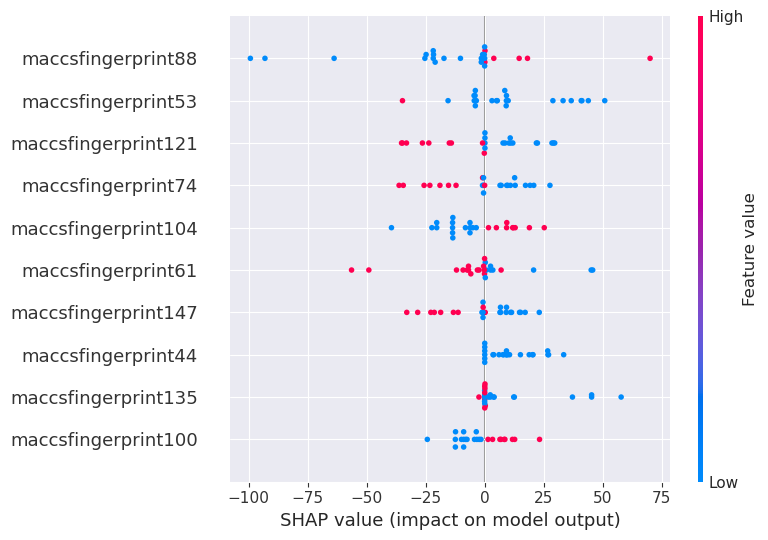

None

In [12]:
column_mapping2 = {feature_names[i]: f"maccsfingerprint{i}" for i in range(len(feature_names))}
visualize_shap(f_importance_rf, X_all, column_mapping2)

In [27]:
ids = [88, 53, 121, 74, 104, 61, 147, 44, 135, 100, 102, 156, 122]
features = [column_mapping[f"maccsfingerprint{i}"] for i in ids]
feature_dict = {f"maccsfingerprint{ids[i]}": features[i] for i in range(len(ids))}
feature_dict

{'maccsfingerprint88': 'OAAAO',
 'maccsfingerprint53': 'QHAAQH',
 'maccsfingerprint121': 'AN(A)A',
 'maccsfingerprint74': 'A!N$A',
 'maccsfingerprint104': 'A$A($A)$A',
 'maccsfingerprint61': 'A$!A$A',
 'maccsfingerprint147': 'AQ(A)A',
 'maccsfingerprint44': 'C=CN',
 'maccsfingerprint135': 'O=A>1 ',
 'maccsfingerprint100': '8M Ring or larger',
 'maccsfingerprint102': 'CL',
 'maccsfingerprint156': 'C-O',
 'maccsfingerprint122': 'OCO'}

In [28]:
smarts = {
    'OAAAO': "[#8]~*~*~*~[#8]",
    'QHAAQH': "[!#6;!#1;!H0]~*~*~[!#6;!#1;!H0]",
    'AN(A)A': "*~[#7](~*)~*",
    'A!N$A': "*!@[#7]@*",
    'A$A($A)$A': "*@*(@*)@*",
    'A$!A$A': "*@*!@*@*",
    'AQ(A)A': "*~[!#6;!#1](~*)~*",
    'C=CN': "[#6]=[#6]~[#7]",
    'O=A>1 ': "[#8]=*",
    'CL': "Cl",
    'C-O': "[#6]-[#8]",
    'OCO': "[#8]~[#6]~[#8]",
}

In [23]:
print(column_mapping['maccsfingerprint103'])

QHACH2A


In [25]:
smarts.keys()

dict_keys(['OAAAO', 'QHAAQH', 'AN(A)A', 'A!N$A', 'A$A($A)$A', 'A$!A$A', 'AQ(A)A', 'C=CN', 'O=A>1 ', 'CL', 'C-O', 'OCO'])

In [29]:
good_molecules = {s: [] for s in smarts.keys()}
for key, value in feature_dict.items():
    non_zero_molecules = df_all[df_all[key] == 1]
    non_zero_molecules = non_zero_molecules['smiles'].tolist()
    if value != '8M Ring or larger':
        good_molecules[value].extend(non_zero_molecules)
good_molecules

{'OAAAO': ['N#Cc1ccc(-n2c(=O)c3cc4c(=O)n(-c5ccc(C#N)cc5)c(=O)c4cc3c2=O)cc1',
  'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(-n4c(=O)c5cc6c(=O)oc(=O)c6cc5c4=O)cc3)n2)cc1',
  'Nc1ccc(-c2nc(-c3ccc(N)cc3)nc(-c3ccc(N4C(=O)c5ccc6c7c(ccc(c57)C4=O)C(=O)OC6=O)cc3)n2)cc1',
  'Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(N=Cc4c(O)c(C=O)c(O)c(C=O)c4O)nc3)n2)cn1',
  'Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(N=Cc4cc(C=O)c(O)c(C=O)c4O)nc3)n2)cn1',
  'Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(N=Cc4cc(C=O)cc(C=O)c4O)nc3)n2)cn1',
  'Nc1cc2sc(-c3c(O)c(-c4nc5cc(S)c(N)cc5s4)c(O)c(-c4nc5cc(S)c(N)cc5s4)c3O)nc2cc1S',
  'Nc1ccc(-c2ccc3[nH]c(-c4cc(-c5nc6ccc(-c7ccc(N)c(N)c7)cc6[nH]5)cc(N5C(=O)c6ccc7c8c(ccc(c68)C5=O)C(=O)N(c5cc(-c6nc8cc(-c9ccc(N)c(N)c9)ccc8[nH]6)cc(-c6nc8ccc(-c9ccc(N)c(N)c9)cc8[nH]6)c5)C7=O)c4)nc3c2)cc1N',
  'Nc1ccc(-c2ccc3[nH]c(-c4cc(-c5nc6ccc(-c7ccc(N)c(N)c7)cc6[nH]5)cc(N5C(=O)c6ccc7c8ccc9c%10c(ccc(c%11ccc(c6c7%11)C5=O)c%108)C(=O)N(c5cc(-c6nc7cc(-c8ccc(N)c(N)c8)ccc7[nH]6)cc(-c6nc7ccc(-c8ccc(N)c(N)c8)cc7[nH]6)c5)C9=O)c4)nc

OAAAO


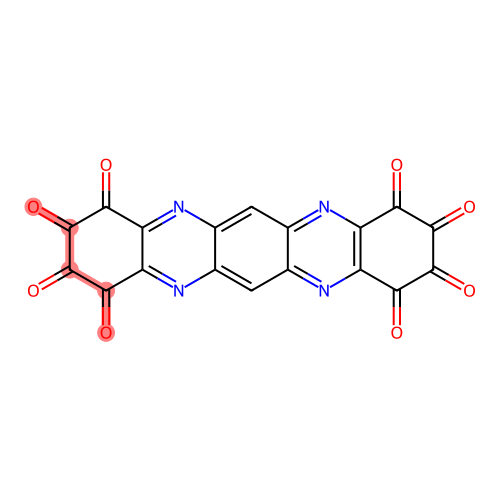

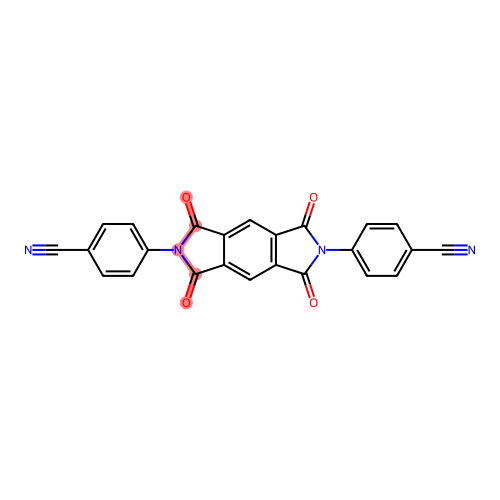

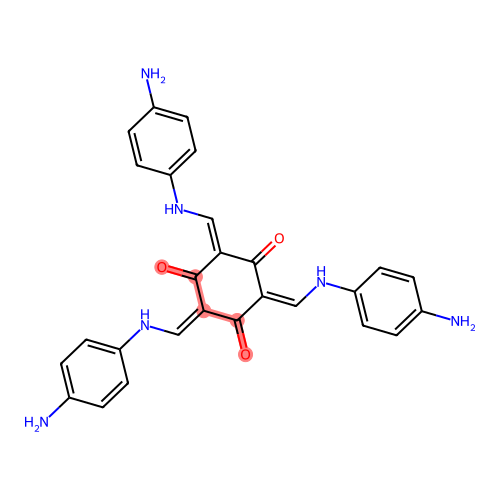

QHAAQH


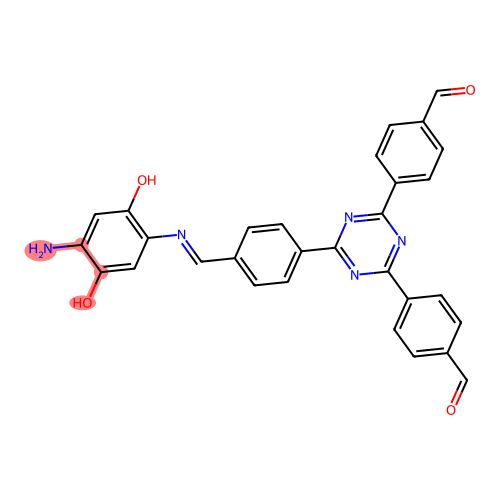

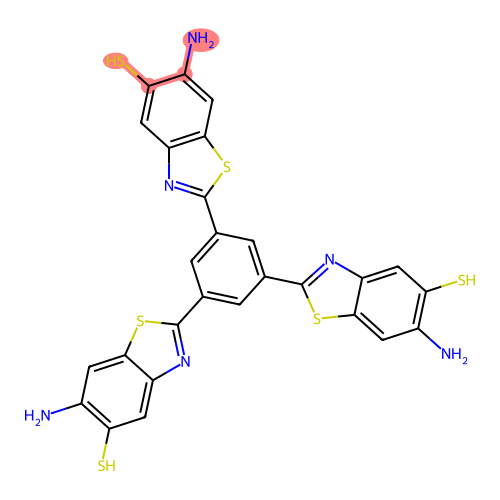

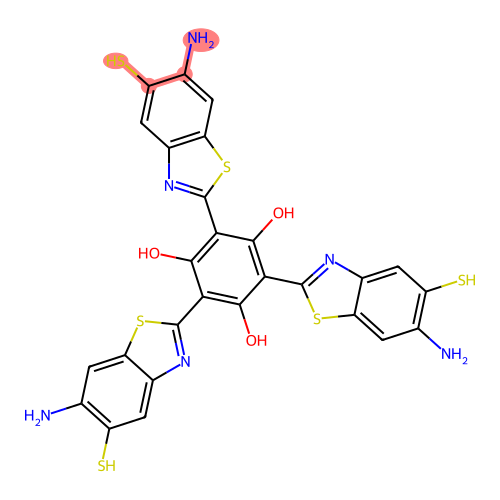

AN(A)A


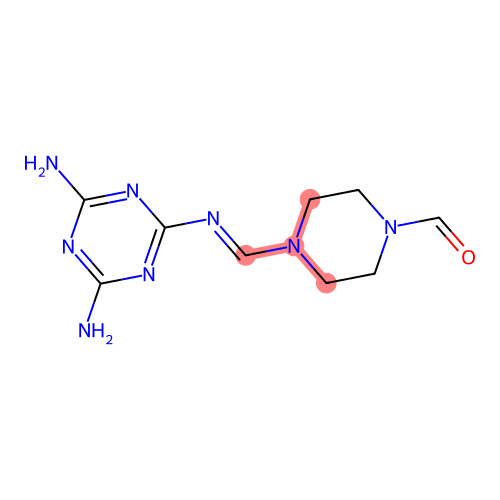

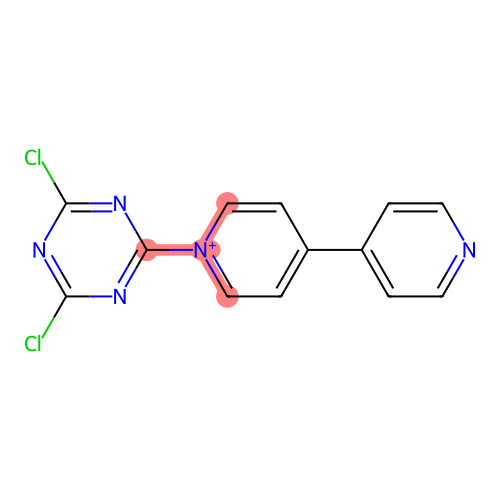

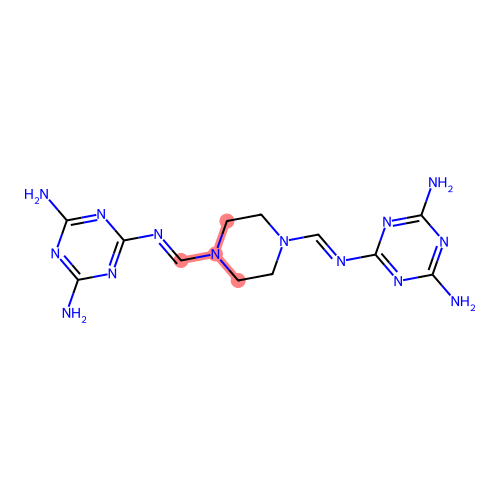

A!N$A


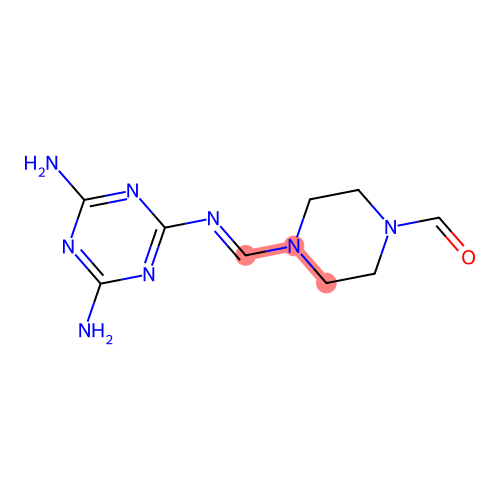

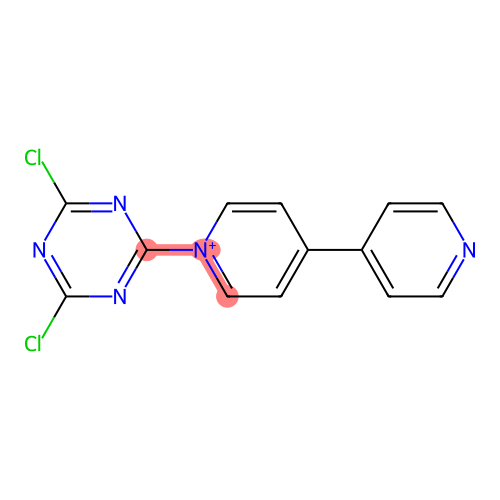

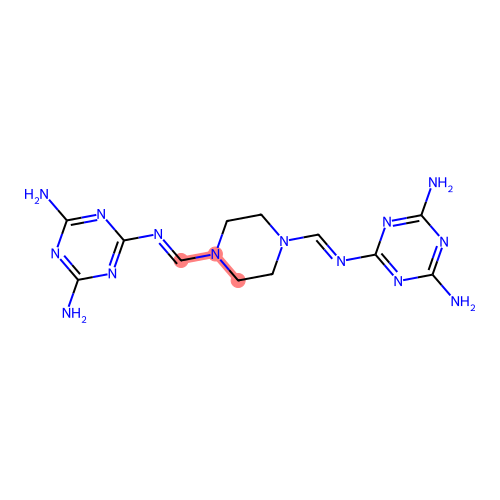

A$A($A)$A


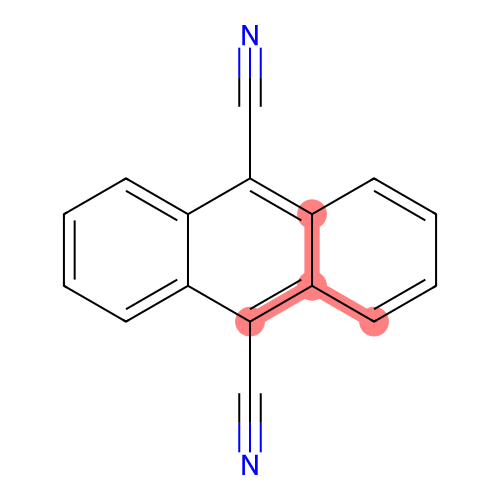

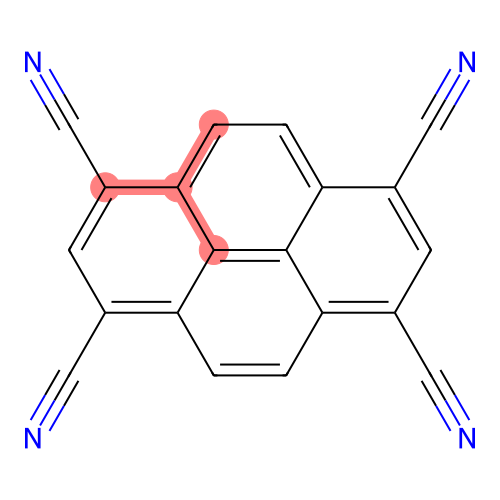

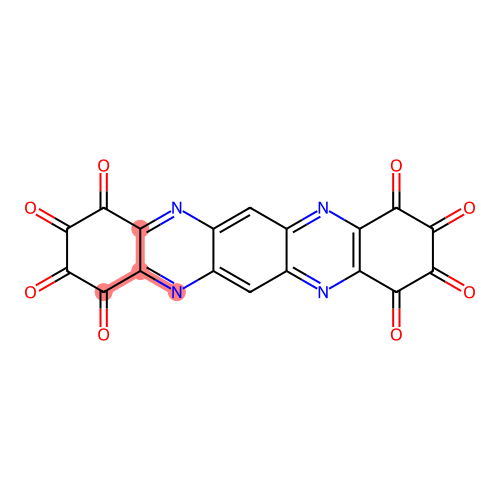

A$!A$A


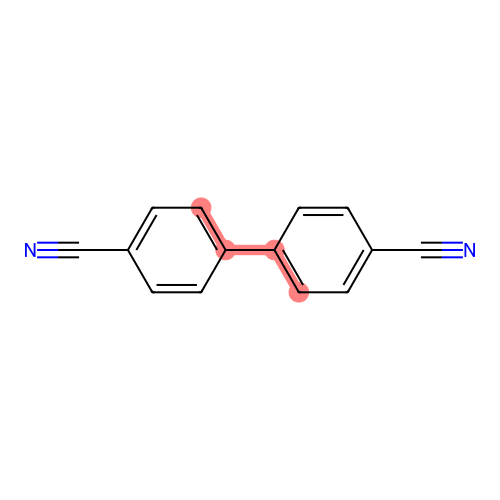

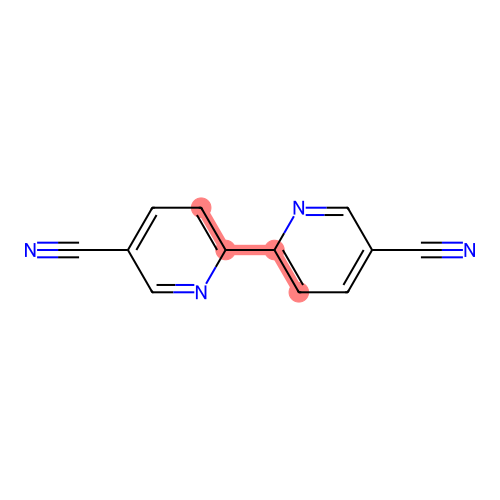

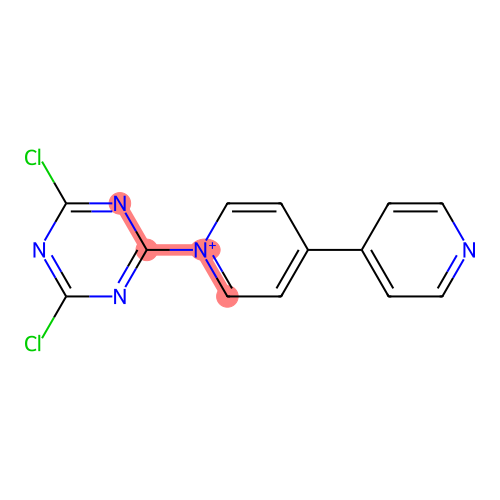

AQ(A)A


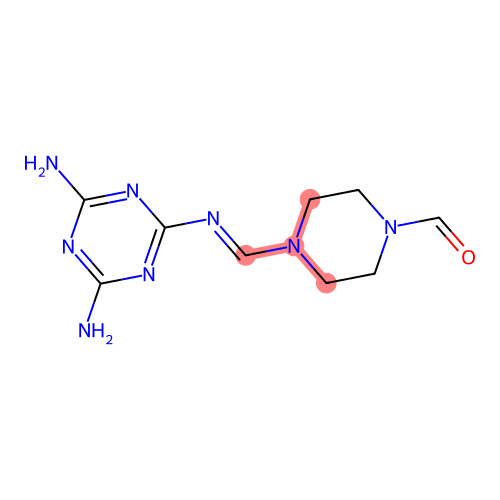

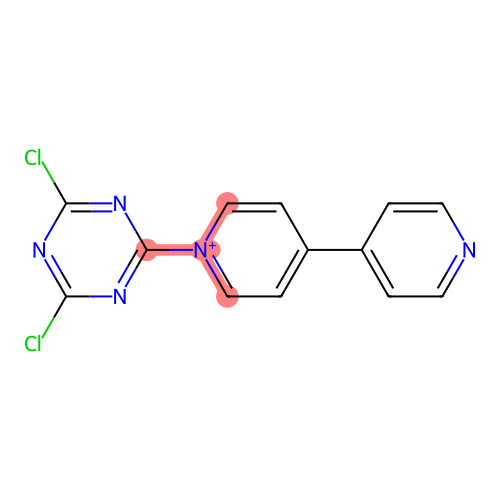

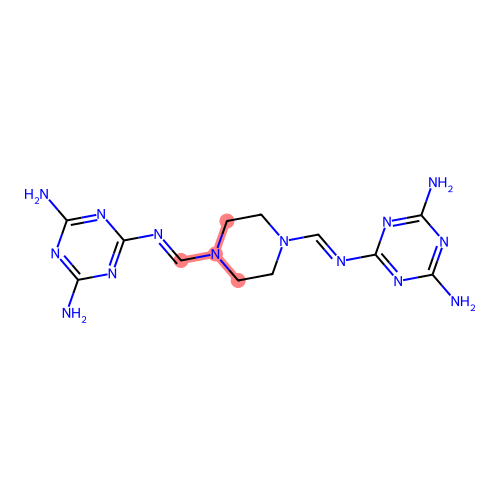

C=CN


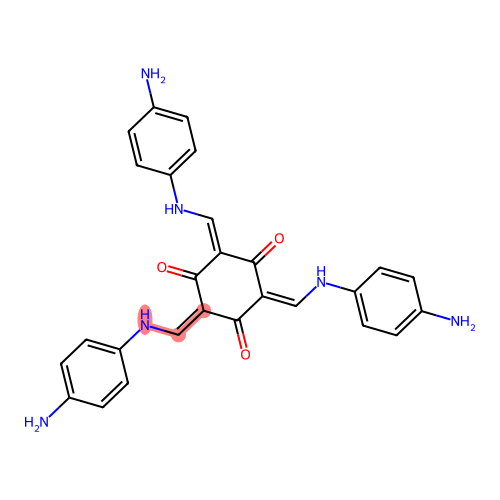

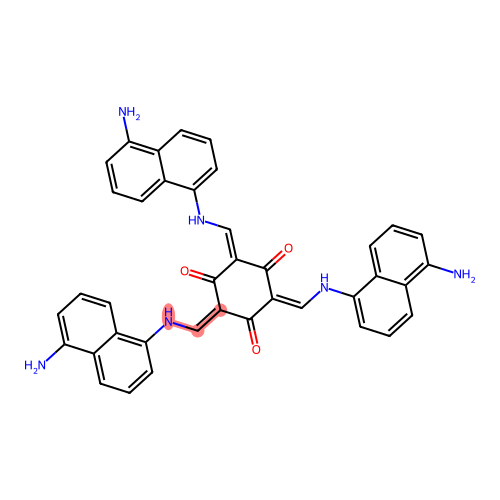

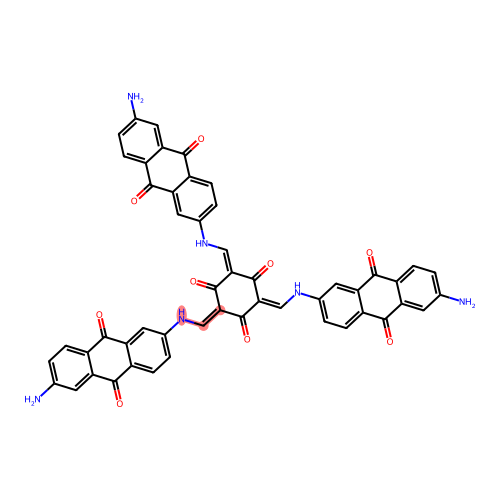

O=A>1 


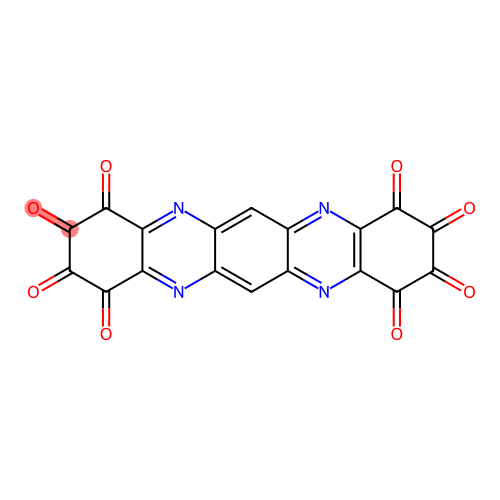

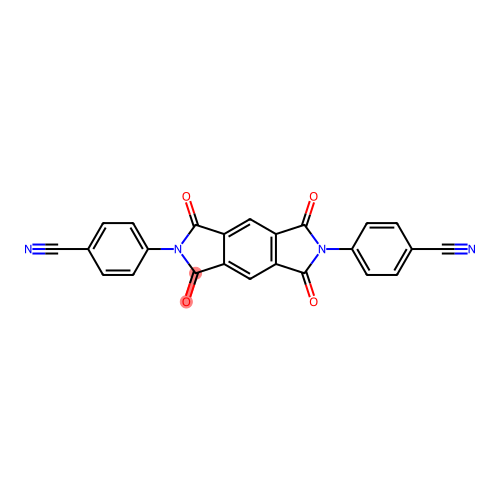

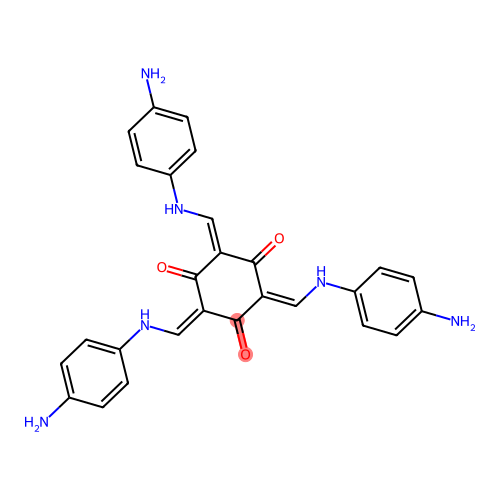

CL


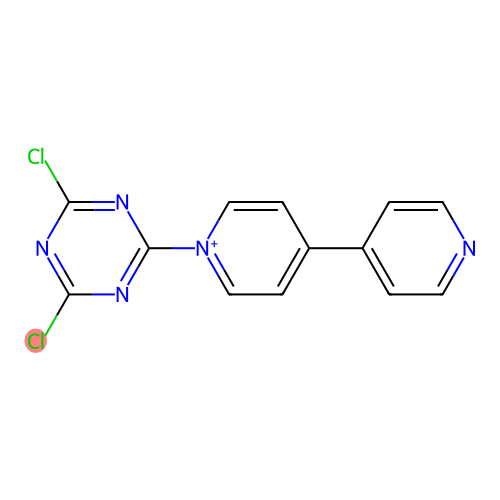

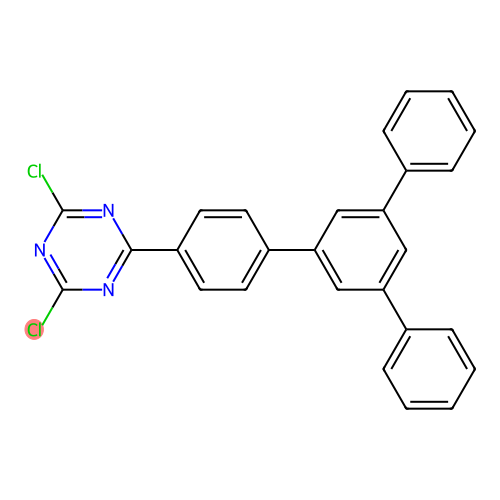

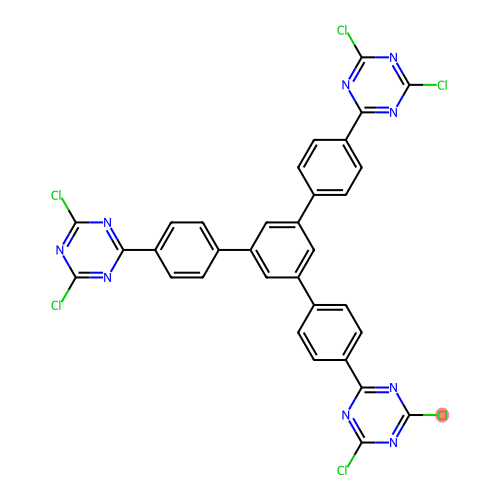

C-O


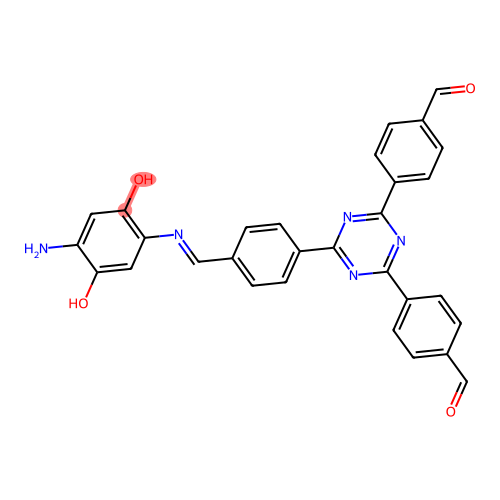

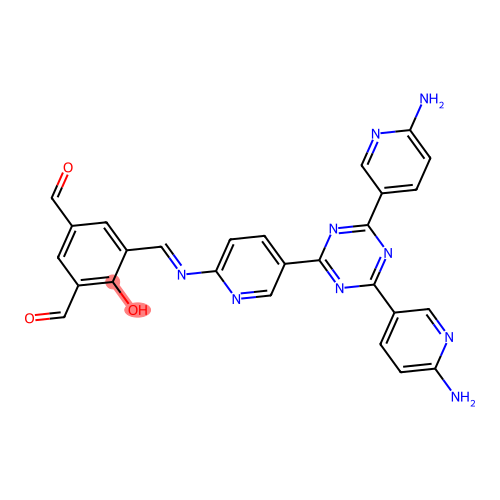

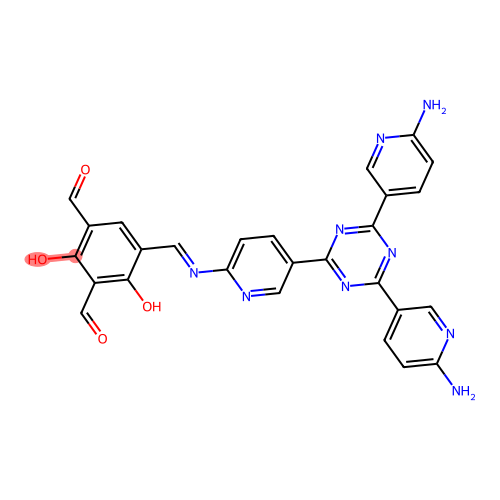

OCO


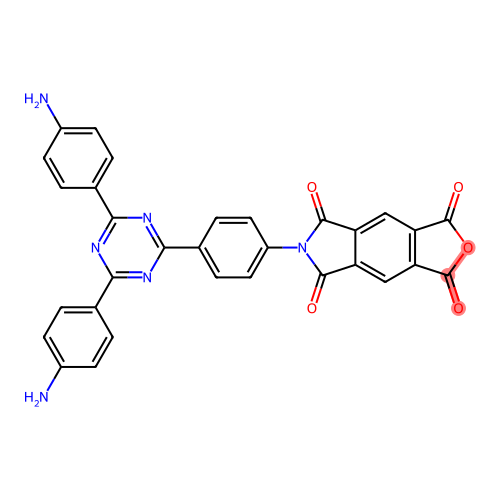

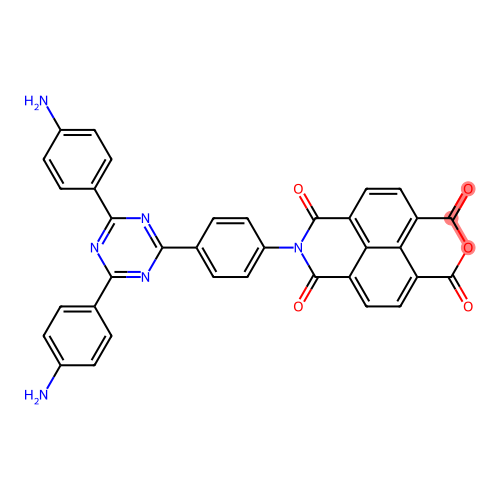

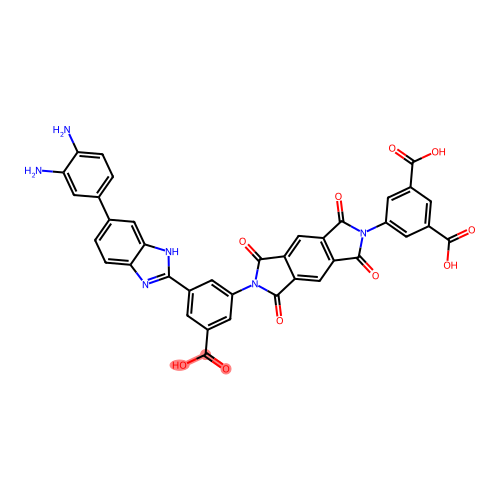

In [31]:
from rdkit import rdBase
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

for key in good_molecules.keys():
    print(key)
    mols = [Chem.MolFromSmiles(smi) for smi in sorted(good_molecules[key], key=lambda x: len(x))]
    match_smart = Chem.MolFromSmarts(smarts[key])
    #match_smart.Compute2DCoords()
    # for mol in mols:
    #     mol.Compute2DCoords()
    #     AllChem.GenerateDepictionMatching2DStructure(mol, match_smart, acceptFailure = True)
    highlight_lists = [mol.GetSubstructMatch(match_smart) for mol in mols]
    # print(highlight_lists[0])
    # display(Draw.MolsToImage([mols[0]], highlightAtomLists = [highlight_lists[0]], subImgSize=(500, 500)))
    for mol, h_list in zip(mols[:3], highlight_lists[:3]):
        display(Draw.MolsToGridImage([mol],
                             highlightAtomLists = [h_list],
                             molsPerRow=1,
                             subImgSize=(500, 500)
                            ))

In [15]:
results_xgboost = cv_xgboost.train_pipeline(models[1])
f_importance_xgboost = cv_xgboost.shap_values

Training model XGBoost Regressor
Best score: -2.5889819197255246
 Best params: {'colsample_bytree': 0.4, 'gamma': 0.0, 'learning_rate': 0.15, 'max_depth': 5, 'min_child_weight': 5}


/home/annprz/miniforge3/envs/battery/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best score: -1.4649606385210956
 Best params: {'colsample_bytree': 0.4, 'gamma': 0.0, 'learning_rate': 0.15, 'max_depth': 5, 'min_child_weight': 1}
Best score: -0.5370270958134933
 Best params: {'colsample_bytree': 0.2, 'gamma': 0.0, 'learning_rate': 0.15, 'max_depth': 5, 'min_child_weight': 3}
Best score: -0.5541835968415039
 Best params: {'colsample_bytree': 0.2, 'gamma': 0.0, 'learning_rate': 0.15, 'max_depth': 5, 'min_child_weight': 5}


In [16]:
print(results_xgboost)

{'pairwise_accuracy_score': 0.725, 'baseline_mean_pairwise_accuracy_score': 0.5, 'baseline_median_pairwise_accuracy_score': 0.5, 'ndcg_score': 0.939, 'baseline_mean_ndcg_score': 0.8519, 'baseline_median_ndcg_score': 0.8519, 'rmse': 95.2273, 'baseline_mean_rmse': 110.5105, 'baseline_median_rmse': 111.3042, 'mape': 0.191, 'baseline_mean_mape': 0.26, 'baseline_median_mape': 0.26, 'selected_features': 'all'}


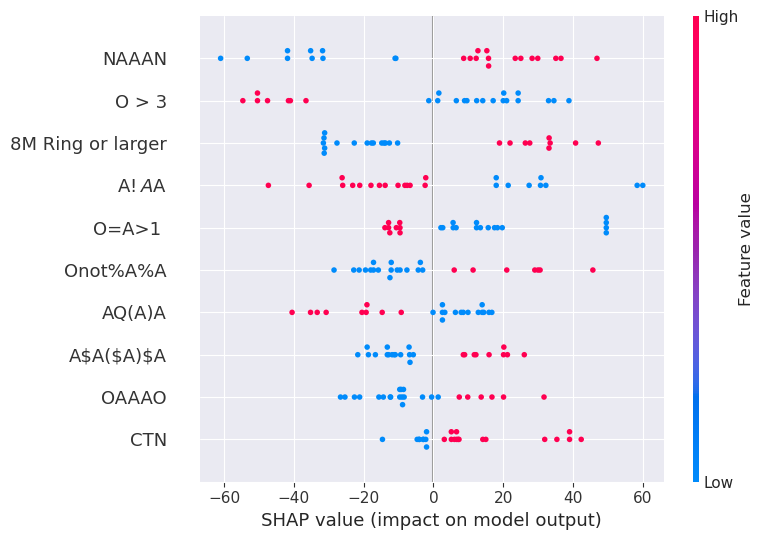

None

In [17]:
visualize_shap(f_importance_xgboost, X_all, column_mapping)

In [ ]:
rf =